![alt text](./Cerny_logo_1.jpg)

# Analysis of Cerny ventilation recordings: `AT000451 - AT000600`

The data processed and analysed in this Notebook were collected by the **Neonatal Emergency and Transport Service of the Peter Cerny Foundation**, Budapest, Hungary

**Author: Dr Gusztav Belteki**

____

This notebook imports all ventilator data of these recordings (including ventilator parameters, settings, alarms (0.5Hz sampling rate) and waveform data (150Hz sampling rate).

- Total: **150 cases**
- 13 cases were removed as they were less than 5 minutes long (empty or partial recordings) 
- **137 cases** remaining

A dictionary containing the processed ventilation data exported as pickle archive: **data_pars_451_600.pickle** 

### 1. Import the required libraries and set options

In [4]:
import IPython
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import os
import sys
import pickle
import datetime

from pandas import Series, DataFrame
from datetime import datetime, timedelta
from matplotlib import dates

%matplotlib inline
matplotlib.style.use('classic')
matplotlib.rcParams['figure.facecolor'] = 'w'
pd.set_option('display.max_rows', 300)
pd.set_option('display.max_columns', 300)

# This is to turn off a warning message which is given when read_Excel() imports '.xlsx' files
import warnings
warnings.simplefilter("ignore")

In [5]:
print("Python version: {}".format(sys.version))
print("pandas version: {}".format(pd.__version__))
print("matplotlib version: {}".format(matplotlib.__version__))
print("NumPy version: {}".format(np.__version__))
print("IPython version: {}".format(IPython.__version__))

Python version: 3.12.11 | packaged by conda-forge | (main, Jun  4 2025, 14:38:53) [Clang 18.1.8 ]
pandas version: 2.3.2
matplotlib version: 3.10.6
NumPy version: 1.26.4
IPython version: 9.5.0


### 2. List and set the working directory and the directory to write out data

In [7]:
# Name of the external hard drive
DRIVE = 'GB_1'

# Batch containing subsets of recording
BATCH = '451_600'

# Directory on external drive to read the ventilation data from
DIR_READ =  os.path.join(os.sep, 'Volumes', DRIVE, 'Ventilator_data', 'Fabian_new', f'fabian_ventilator_data_new_{BATCH}')

# Path to project folder containing ventilation research results
PATH = os.path.join(os.sep, 'Users', 'guszti', 'Library', 'Mobile Documents', 'com~apple~CloudDocs', 
                            'Documents', 'Research', 'Ventilation')

# Folder to export the result of analysis
DIR_WRITE = os.path.join(PATH, 'ventilation_fabian_new', 'Analyses')
os.makedirs(DIR_WRITE, exist_ok = True)

# Folder containing log files containing errors and anomalies arising during data processing
ERROR_LOGS = os.path.join(DIR_WRITE, 'error_logs')
os.makedirs(ERROR_LOGS, exist_ok = True)

# Folder on a USB stick to export data to
DATA_DUMP = os.path.join(os.sep, '/Volumes', DRIVE, 'data_dump', 'fabian_new',)
os.makedirs(DATA_DUMP, exist_ok = True)

In [8]:
DIR_READ, DIR_WRITE, DATA_DUMP

('/Volumes/GB_1/Ventilator_data/Fabian_new/fabian_ventilator_data_new_451_600',
 '/Users/guszti/Library/Mobile Documents/com~apple~CloudDocs/Documents/Research/Ventilation/ventilation_fabian_new/Analyses',
 '/Volumes/GB_1/data_dump/fabian_new')

### 3. Import ventilation data as text and create a dictionary of the different recordings

In [10]:
cases = os.listdir(DIR_READ)
cases = sorted(case for case in cases if case.startswith('AT')) # remove hidden other files
len(cases)

150

In [11]:
%%time

# import all data file in the vent_dict dictionary
vent_dict = {}
for case in cases:
    flist = os.listdir(os.path.join(DIR_READ, case))
    for fle in flist:
        if not fle.startswith('.') and fle.endswith('txt'):
            fle_handle = open(os.path.join(DIR_READ, case, fle), 'r', encoding = 'latin1')
            vent_dict['%s_%s' % (case, fle[-5])] = fle_handle.read()
            fle_handle.close()
len(vent_dict)

CPU times: user 1.33 s, sys: 1.25 s, total: 2.57 s
Wall time: 6.22 s


353

### 4. Split recordings into records

In [13]:
%%time

with open(os.path.join(ERROR_LOGS, f'{BATCH}_error_log_1.txt'), 'w') as fileout:

    data_dict = {} # In this dict the keys are time points and the values are vent data
    for key, value in sorted(vent_dict.items()):
        data_list = value.split('\n') # Individual records are separated by a 'newline' character
        data_dict[key] = {} # an inner dictionary for the given recording
        for number, record in enumerate(data_list[:-1]):
            try:
                time_stamp, data_str = record.split(';') # splitting record to time stamp and ventilation data
                data_dict[key][time_stamp] = data_str       
            except:
                print('In %s, record #%d cannot be parsed: \n %s' % (key, number, record[:75]), '\n', file=fileout)

CPU times: user 2.6 s, sys: 1.07 s, total: 3.67 s
Wall time: 4.1 s


### 5. Combine data dictionaries from the same cases

In [15]:
%%time

# data_dict_2 contains the combined ventilation data for each case
data_dict_2 = {}
for case in cases:
    dicts_to_combine = []
    for recording in vent_dict.keys():
        if recording.startswith(case):
            dicts_to_combine.append(data_dict[recording])
    data_dict_2[case] = {k: v for dct in dicts_to_combine for k, v in dct.items()} 

CPU times: user 194 ms, sys: 1.04 s, total: 1.23 s
Wall time: 1.66 s


### 6. Separate parameter data and waves data

In [17]:
%%time

# Records containing parameter data start with '<', records containing waves data always have a space (' ')
# after the first byte (two characters in hexadecimal notation)
with open(os.path.join(ERROR_LOGS, f'{BATCH}_error_log_2.txt'), 'w') as fileout:

    data_dict_waves = {}
    data_dict_pars = {}
    for case in cases:
        data_dict_waves[case] = {}
        data_dict_pars[case] = {}
        for key, value in sorted(data_dict_2[case].items()):
            if value.startswith('<'): # These are ventilator parameter slow data  
                data_dict_pars[case][key] = value[13:-12] # removing 13 characters from the 
                # beginnings and 12 characters from the end (they are not parameters)
            elif value[2] == ' ': # Waves data have a space character at the third position
                data_dict_waves[case][key] = value
            else:
                print(f'In %s, record #%d cannot be parsed: \n %s' % (key, number, record[:75]), '\n',  file=fileout)

CPU times: user 737 ms, sys: 1.14 s, total: 1.88 s
Wall time: 2.26 s


### 7. Create nested dictionary for the various parameters and their values

In [19]:
%%time

with open(os.path.join(ERROR_LOGS, f'{BATCH}_error_log_3.txt'), 'w') as fileout:

    data_dict_pars_2 = {}
    for case in cases:
        data_dict_pars_2[case] = {}
        for time, values in data_dict_pars[case].items():
            time = datetime.strptime(time[:-4], '%m/%d/%Y %I:%M:%S %p')
            data_dict_pars_2[case][time] = {} # inner dictionary with the time stamps used as keys
            for pair in values.split('|'):
                if ',' in pair: # ventilator software version field contains a comma
                    continue
                
                try:
                    code, value = pair.split('=') # split records into parameter keys and values
                except:
                    print('In case %s this record at cannot be unpacked:\n %s, %s\n' % (case, time, pair), file = fileout)
                    continue
                
                if code.startswith('0'): # The codes <10 start with zeros (e.g. 00, 01, 02,...)
                                         # and the leading zeros need to be removed
                    code = code[1:]  
                
                try:
                    parameter = int(code)
                except ValueError:
                    print('In case %s at %s error during coverting value to int:\n%r\n' % (case, time,code), file = fileout)
                    continue
            
                if code == '145': # Device ID variant, hexadecimal number
                    data_dict_pars_2[case][time][parameter] = value
                    
                elif code == '125': 
                    # convert Mode options 1 to binary number to retrieve bits
                    data_dict_pars_2[case][time][parameter] = bin(int(value))[2:].zfill(16)
                    
                elif code == '126': 
                    # convert Mode options 2 to binary number to retrieve bits
                    data_dict_pars_2[case][time][parameter] = bin(int(value))[2:].zfill(16)
            
                elif '.' in value or value == '0':
                
                    try:
                        data_dict_pars_2[case][time][parameter] = float(value)
                    except ValueError:
                        print('In case %s at %s, value cannot be converted to float\n:%r\n' % (case, time, value), file = fileout)
                        continue
                else: 
                    try:
                        data_dict_pars_2[case][time][parameter] = int(value)
                    except:
                        print('In case %s at %s, value cannot be converted to int\n:%r\n' % (case, time, value), file = fileout)
                        continue

CPU times: user 34.1 s, sys: 1.01 s, total: 35.1 s
Wall time: 36.1 s


In [20]:
%%time

# Parameter #125 is 'Mode option 1': its different bits are meaning different parameters
# Parameter #126 is 'Mode option 2': its different bits are meaning different parameters
# See Aculink protocol for more details
with open(os.path.join(ERROR_LOGS, f'{BATCH}_error_log_4.txt'), 'w') as fileout:

    for case in cases:
        for time in sorted(data_dict_pars_2[case].keys()):
            try:
                # Ventilation_stopped; 0 = no, 1 = yes
                data_dict_pars_2[case][time][276] = int(data_dict_pars_2[case][time][125][-1])
                # VG_state: 0 = off, 1 = on
                data_dict_pars_2[case][time][277] = int(data_dict_pars_2[case][time][125][-2])
                # Volume limit state: 0 = off, 1 = on
                data_dict_pars_2[case][time][278] = int(data_dict_pars_2[case][time][125][-3]) 
                # Ventilator_range: 0  = neonatal, 1 = paediatric
                data_dict_pars_2[case][time][279] = int(data_dict_pars_2[case][time][125][-4])
            
                # trigger_mode: 0 = volumetrigger, 1 = flowtrigger
                data_dict_pars_2[case][time][280] = int(data_dict_pars_2[case][time][125][-8])
    
                # I_E_HFOV (HFOV I:E ratio): 0=1:3, 1=1:2, 2=1:1
                if data_dict_pars_2[case][time][125][-14:-12] == '00':
                    data_dict_pars_2[case][time][281] = 0
                elif data_dict_pars_2[case][time][125][-14:-12] == '01':
                    data_dict_pars_2[case][time][281] = 1
                elif data_dict_pars_2[case][time][125][-14:-12] == '10':
                    data_dict_pars_2[case][time][281] = 2
    
                # pressure_rise_control: 0=I-flow, 1=Ramp, 2=AutoIFlow
                if data_dict_pars_2[case][time][126][-2:]   == '00':
                    data_dict_pars_2[case][time][282] = 0
                elif data_dict_pars_2[case][time][126][-2:] == '01':
                    data_dict_pars_2[case][time][282] = 1
                elif data_dict_pars_2[case][time][126][-2:] == '10':
                    data_dict_pars_2[case][time][282] = 2
    
                # HFOV recruitment: 0 = off, 1 = on
                data_dict_pars_2[case][time][283] = int(data_dict_pars_2[case][time][126][-3]) 
                # HFOV flow: 0 = off, 1 = on
                data_dict_pars_2[case][time][284] = int(data_dict_pars_2[case][time][126][-4])
                # Bias flow: 0 = off, 1 = on
                data_dict_pars_2[case][time][285] = int(data_dict_pars_2[case][time][126][-6])
            
                # Trigger mode 2: 0=Volumetrigger, 1=Flowtrigger, 2=Pressuretrigger
                if data_dict_pars_2[case][time][126][-8:-6]   == '00':
                    data_dict_pars_2[case][time][286] = 0
                elif data_dict_pars_2[case][time][126][-8:-6] == '01':
                    data_dict_pars_2[case][time][286] = 1
                elif data_dict_pars_2[case][time][126][-8:-6] == '10':
                    data_dict_pars_2[case][time][286] = 2
                
                # FOT oscillation running: 0 = no, 1 = yes
                data_dict_pars_2[case][time][287] = int(data_dict_pars_2[case][time][126][-10])
            
                # Leak compensation: 0=off, 1=Low, 2=Middle, 3=High
                if data_dict_pars_2[case][time][126][-12:-10]   == '00':
                    data_dict_pars_2[case][time][288] = 0
                elif data_dict_pars_2[case][time][126][-12:-10] == '01':
                    data_dict_pars_2[case][time][288] = 1
                elif data_dict_pars_2[case][time][126][-12:-10] == '10':
                    data_dict_pars_2[case][time][288] = 2
                elif data_dict_pars_2[case][time][126][-12:-10] == '11':
                    data_dict_pars_2[case][time][288] = 3
        
            except Exception as e:
               print(f'Error in {case}, {time}', '\n', e, file=fileout)

CPU times: user 1.01 s, sys: 678 ms, total: 1.68 s
Wall time: 2.16 s


### 8. Create DataFrame from Parameters Data

In [22]:
%%time

data_pars = {}
for case in cases:
    data_pars[case] = DataFrame(data_dict_pars_2[case]).T

CPU times: user 6.43 s, sys: 1.22 s, total: 7.65 s
Wall time: 9.47 s


In [23]:
%%time

# Replace codes for text (see Aculink protocol)

for case in cases:
    a = data_pars[case].copy()
    a= a.replace(-32764, 'off')
    a= a.replace(-32765, 'not valid')
    a= a.replace(-32766, 'out of range')
    a= a.replace(-32767, 'unused')
    data_pars[case] = a

CPU times: user 9.74 s, sys: 886 ms, total: 10.6 s
Wall time: 10.9 s


In [24]:
recording_duration = []

for case in cases:
    # The sampling rate is 0.5 Hz (1 in 2 seocnds), e.g. if the lentgh of the DataFrame is 150, its duration # is 5 minutes (300 seconds)
    recording_duration.append((case, 2 * len(data_pars[case])))  

recording_duration = DataFrame(recording_duration)
recording_duration.columns = ['case', 'seconds']
recording_duration.index = recording_duration['case']
recording_duration.drop('case', axis = 1, inplace = True)

In [25]:
recording_duration['seconds'].describe()

count      150.000000
mean      4012.613333
std       2726.239054
min          8.000000
25%       2386.000000
50%       3339.000000
75%       5241.500000
max      14968.000000
Name: seconds, dtype: float64

In [26]:
recording_duration.sort_values(by = 'seconds', ascending = True)[:25]

,seconds
case,
AT000563,8
AT000479,12
AT000520,18
AT000566,24
AT000572,28
AT000561,36
AT000464,38
AT000514,60
AT000492,70


### 9. Remove those recordings which are less than 5 minutes long

Recordings less than 5 minutes (300 seconds) long are very likely incomplete and sometimes completely empty.

In [28]:
len(data_pars)

150

In [29]:
# The sampling rate is 0.5 Hz (1 in 2 seocnds), if the lentgh of the DataFrame is 150, its duration is 5 minutes (300 seconds)

for case in cases:
    if len(data_pars[case]) < 150:
        print('Removing %s' % case)
        del data_pars[case]

cases = sorted(data_pars.keys())

Removing AT000457
Removing AT000464
Removing AT000479
Removing AT000492
Removing AT000514
Removing AT000515
Removing AT000520
Removing AT000521
Removing AT000559
Removing AT000561
Removing AT000563
Removing AT000566
Removing AT000572


In [30]:
len(data_pars)

137

In [31]:
len(cases)

137

### 10. Replace codes for categorical variables with informative category names

In [33]:
mapping_patient_range = {1: 'Neonatal', 2: 'Pediatric'}
for case in cases:
    data_pars[case][100].replace(mapping_patient_range, inplace = True)

In [34]:
mapping_vent_mode = {0: None, 1: 'IPPV', 2: 'SIPPV', 3: 'SIMV', 4: 'SIMVPSV', 5: 'PSV', 
                     6: 'CPAP', 7: 'NCPAP', 8: 'DUOPAP', 9: 'HFO', 10: 'O2therapy', 15: 'service'}
for case in cases:
    data_pars[case][101].replace(mapping_vent_mode, inplace = True)

In [35]:
mapping_power = {0: 'Network', 1: 'Battery'}
for case in cases:
    data_pars[case][127].replace(mapping_power, inplace = True)

In [36]:
mapping_off_on = {0: 'off', 1: 'on'}
for case in cases:
    data_pars[case][157].replace(mapping_off_on, inplace = True)
    data_pars[case][158].replace(mapping_off_on, inplace = True)
    data_pars[case][277].replace(mapping_off_on, inplace = True)
    data_pars[case][278].replace(mapping_off_on, inplace = True)
    data_pars[case][283].replace(mapping_off_on, inplace = True)
    data_pars[case][284].replace(mapping_off_on, inplace = True)
    data_pars[case][285].replace(mapping_off_on, inplace = True)

In [37]:
mapping_no_yes = {0: 'no', 1: 'yes'}
for case in cases:
    data_pars[case][276].replace(mapping_no_yes, inplace = True)
    data_pars[case][287].replace(mapping_no_yes, inplace = True)

In [38]:
mapping_trigger = {0: 'Volumetrigger', 1: 'Flowtrigger'}
for case in cases:
    data_pars[case][280].replace(mapping_trigger, inplace = True)

In [39]:
mapping_IE_HFOV = {0: '1:3', 1: '1:2', 2: '1:1'}
for case in cases:
    data_pars[case][281].replace(mapping_IE_HFOV, inplace = True)

In [40]:
mapping_pressure_rise_ctrl = {0: 'I-flow', 1: 'Ramp', 2: 'AutoIFlow'}
for case in cases:
    data_pars[case][282].replace(mapping_pressure_rise_ctrl, inplace = True)

In [41]:
mapping_pressure_unit = {0: 'mbar', 1: 'cmH2O',}
for case in cases:
    data_pars[case][140].replace(mapping_pressure_unit, inplace = True)

In [42]:
mapping_CO2 = {0: 'mmHg', 1: 'kPa', 2: 'Vol%'}
for case in cases:
    data_pars[case][141].replace(mapping_CO2, inplace = True)

In [43]:
mapping_trigger_2 = {0: 'Volumetrigger', 1: 'Flowtrigger', 2: 'Pressuretrigger'}
for case in cases:
    data_pars[case][286].replace(mapping_trigger_2, inplace = True)

In [44]:
mapping_leak_comp = {0: 'off', 1: 'low', 2: 'middle', 3: 'high'}
for case in cases:
    data_pars[case][288].replace(mapping_leak_comp, inplace = True)

### 11. Parse the parameter values using Fabian parameter library

In [46]:
par_key_table = pd.read_excel(os.path.join(PATH, 'ventilation_fabian_new','Fabian_parameters_new.xlsx'))

In [47]:
par_key_table;

In [48]:
par_key_dict = {}
for row in par_key_table.index:
    par_key_dict[par_key_table.code[row]] = par_key_table.name[row]

In [49]:
for case in cases:
    data_pars[case].rename(columns = par_key_dict, inplace = True )

### 12. Sort DataFrames according to time stamp index

In [51]:
for case in cases:
    data_pars[case].sort_index(inplace = True)

### 13. Write individual text files with the ventilator modes

##### Create sub-directories for each case if it does not yet exist

In [54]:
# Images and raw data will be written on an external hard drive
os.makedirs(os.path.join(DATA_DUMP, 'fabian_cases_new'), exist_ok = True)

for case in cases: 
    os.makedirs(os.path.join(DATA_DUMP, 'fabian_cases_new', case), exist_ok = True)

In [55]:
for case in cases:
    a = data_pars[case]
    
    o2therapy = len(a[a['Ventilator_mode'] == 'O2therapy'])
    ncpap = len(a[a['Ventilator_mode'] == 'NCPAP'])
    duopap = len(a[a['Ventilator_mode'] == 'DUOPAP'])
    simv = len(a[a['Ventilator_mode'] == 'SIMV'])
    ippv = len(a[a['Ventilator_mode'] == 'IPPV'])
    sippv = len(a[a['Ventilator_mode'] == 'SIPPV'])
    simvpsv = len(a[a['Ventilator_mode'] == 'SIMVPSV'])
    hfo = len(a[a['Ventilator_mode'] == 'HFO'])
    vg_on = len(a[a['VG_state'] == 'on']) 
    fileout = open(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_vent_info_unedited.txt'), 'w')
    
    fileout.write('O2 therapy: %d sec \n' % (o2therapy * 2))
    fileout.write('NCPAP:      %d sec \n' % (ncpap * 2))
    fileout.write('DUOPAP:     %d sec \n' % (duopap * 2))
    fileout.write('IPPV:       %d sec \n' % (ippv * 2))
    fileout.write('SIPPV:      %d sec \n' % (sippv * 2))
    fileout.write('SIMV:       %d sec \n' % (simv * 2))
    fileout.write('SIMVPSV:    %d sec \n' % (simvpsv * 2))
    fileout.write('HFO:        %d sec \n\n' % (hfo * 2))
    fileout.write('VG on:      %d sec \n' % (vg_on * 2))
    
    fileout.close()

### 14. Generate graph showing ventilator modes

In [57]:
mapping_vent_mode = {1: 'IPPV', 2: 'SIPPV', 3: 'SIMV', 4: 'SIMVPSV', 5: 'PSV', 
                     6: 'CPAP', 7: 'NCPAP', 8: 'DUOPAP', 9: 'HFO', 10: 'O2therapy'}
mapping_vent_mode_rev = {value:key for key, value in mapping_vent_mode.items()}
mapping_vent_mode_rev

{'IPPV': 1,
 'SIPPV': 2,
 'SIMV': 3,
 'SIMVPSV': 4,
 'PSV': 5,
 'CPAP': 6,
 'NCPAP': 7,
 'DUOPAP': 8,
 'HFO': 9,
 'O2therapy': 10}

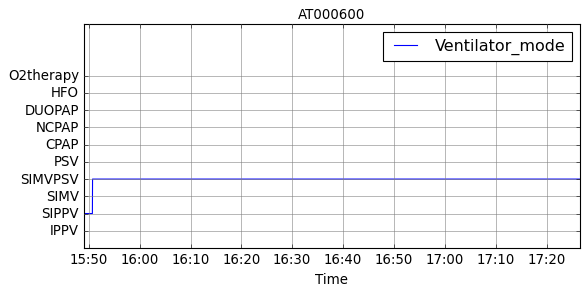

CPU times: user 7.66 s, sys: 395 ms, total: 8.06 s
Wall time: 8.49 s


In [58]:
%%time

par = 'Ventilator_mode'
dim = 'cmH$_2$O'; filetype = 'jpg'; dpi = 200

for case in cases:
    
    fig = plt.figure()
    fig.set_size_inches(8, 4)
    fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.1)
        
    ax = fig.add_subplot(1, 1, 1)
    data = data_pars[case][par].replace(mapping_vent_mode_rev).astype('float').dropna()
    data.plot(ax = ax, label = par, x_compat = True)
    ax.set_xlabel('Time', size = 12, color = 'black')
    ax.set_ylabel('', size = 12, color = 'black')
    ax.set_ylim(0,13)
    ax.set_yticks(sorted(mapping_vent_mode_rev.values()))
    ax.set_yticklabels(mapping_vent_mode_rev.keys())
    ax.set_title(case,  size = 12, color = 'black')
    ax.legend()
    ax.grid(True, linestyle='-', linewidth=0.5, color = 'gray')
    
    majorFmt = dates.DateFormatter('%H:%M')  
    ax.xaxis.set_major_formatter(majorFmt)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize = 12, horizontalalignment = 'center')
    ax.tick_params(which = 'both', labelsize=12)
            
    fig.savefig(os.path.join(DATA_DUMP, 'fabian_cases_new', case, f'{case}_unedited_ventilation_mode.{filetype}'), 
        dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1,);
    
    if case != cases[-1]:
        plt.close()
    plt.show()

### 15. Export processed data as pickle files

In [60]:
with open(os.path.join(DATA_DUMP, f'data_pars_{BATCH}.pickle'), 'wb') as handle:
    pickle.dump(data_pars, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [61]:
with open(os.path.join(DATA_DUMP, f'cases_{BATCH}.pickle'), 'wb') as handle:
    pickle.dump(cases, handle, protocol=pickle.HIGHEST_PROTOCOL)